# Deep Learning Systems Project

Semantic Segmentation of the Martian Landscape based on camera data from the Curiosity Rover

Our task is to try and build a light-weight Semantic Segmentation Model that could theoretically be used on an actually Mars Rover mission for Navigational purposes.

### Gene Foxwell

### Dataset: https://www.kaggle.com/datasets/darshannnnnn/ai4mars-raw

## Overview

We will conduct an experiment on the UNet Segmentation Model. Using the AI4Mars dataset we will extract the greyscale Curiosity Rover data and convert the labels so we have a binary classification problem (with respect to Segmentation). Pixels will either be marked transversable (1) or non-transversable (0).

We will train a Classic UNet (with the addition of BatchNorm) as well as a UNet with a significantly reduced set of parameters on this dataset. We will then compare the results to see if the resulting model is still able to perform well enough that it could still be theorectically useful on image data from Curiosity Rover.

Finally, we will provide a short summary and comparison of the results.

Let's get started...

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import random
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split

import segmentation_models_pytorch as smp

from tqdm import tqdm

C:\Users\genef\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


Verify CUDA is available...

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Step 1: Load Dataset

The dataset is too large to keep in github, so we'll download it programmatically.

In [3]:
path = kagglehub.dataset_download("darshannnnnn/ai4mars-raw")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\genef\.cache\kagglehub\datasets\darshannnnnn\ai4mars-raw\versions\1


In [4]:
dataset_path = os.path.join(path, "ai4mars-dataset-merged-0.6")

### About the Dataset

This dataset contains images and corresponding labels from:

* Curiosity Rover
* Spirit and Opportunity
* Mars 2020 Rover

Labels are done on a per-pixel basis, making this dataset appropriate for image segmentation. The pixels are labelled as follows:

* 0 - soil
* 1 - bedrock
* 2 - sand
* 3 - big rock
* 255 - NULL (no label)

Labels were created via a crowdsourcing. Details on the data labeling can be found in https://openaccess.thecvf.com/content/CVPR2021W/AI4Space/html/Swan_AI4MARS_A_Dataset_for_Terrain-Aware_Autonomous_Driving_on_Mars_CVPRW_2021_paper.html

We will focus on data from the Curiosity Rovers navigational camera.

Our goal is to build a lightweight system that could potentially be used on an actual Rover for navigation. To that end, we're going to remap the provided labels into a binary classification problem. Pixels marked with 0 are non-transversable (the Rover should avoid them), pixels marked with 1 are transversible (Rover may drive on them.) We'll perform this mapping as follows:

* soil/bedrock -> 1
* sand / big rock / 255 -> 0

We will assume unlabeled data is undrivable. This helps avoid the risk of pushing the rover onto unfamiliar terrain and potentially losing it entirely.



### Sample Images

Let's start by taking a look at some sample images from each Rover. To do this we'll create a couple of helper functions for loading and displaying the images

In [5]:
def load_label(label_folder, base_name, img_array):
    """
    Loads a training label for the given label_folder and base_name of the image.

    Args:
        label_folder: Source folder for the labels.
        base_name: Base name for the image we want the label for.
        img_array: numpy array representing our source image.

    Returns:
        The label image, if it exists, otherwise an empty mask
    """
    label_name = f"{base_name}.png"
    label_path = os.path.join(label_folder, label_name)

    if os.path.exists(label_path):
            label = Image.open(label_path)
            return np.array(label)
    

    # handle the Mars Science Label Labels.
    for i in range(3, 10):
        label_name = f"{base_name}_merged{i}.png"
        label_path = os.path.join(label_folder, label_name)

        if os.path.exists(label_path):
            label = Image.open(label_path)
            return np.array(label)

    print(f"Warning: Label not found for {label_path}")
    return np.zeros(img_array.shape[:2]) 


def fetch_random_image_and_label(source_folder, label_folder):
    """
    Fetches a random image from the source folder along with its corresponding label.

    Args:
        source_folder: The folder to grab the image from.
        label_folder: The folder to grab the masking image from.

    Returns:
        Two numpy arrays representing the source image and its corresponding label
    """

    # Get the list of images.
    try:
        all_images = [f for f in os.listdir(source_folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    except FileNotFoundError:
        print(f"Error: Could not find directory {source_folder}")
        return None, None

    if not all_images:
        print("No images found in the specified directory.")
        return None, None

    random_image_name = random.choice(all_images)

    base_name = os.path.splitext(random_image_name)[0]
    label_name = f"{base_name}.png"

    image_path = os.path.join(source_folder, random_image_name)
    label_path = os.path.join(label_folder, label_name)

    try:
        # Load Image
        img = Image.open(image_path).convert('RGB')
        img_array = np.array(img)

        # Load Label
        label_array = load_label(label_folder, base_name, img_array)
            
        return img_array, label_array

    except Exception as e:
        print(f"An error occurred while loading: {e}")
        return None, None

In [6]:
def display_image_and_label(image, label, file_name):
    """
    Diplays the image and its corresponding label side by side.

    Args:
        image: The source image to display.
        label: The label to display alongside it.
        file_name: file to save the resulting plot to.
    """
    if image is not None and label is not None:
        fig, axes = plt.subplots(1, 2, figsize=(15, 7))

        # Display the Raw Image
        axes[0].imshow(image)
        axes[0].set_title("Original Rover Image")
        axes[0].axis('off')

        im = axes[1].imshow(label, cmap='viridis') 
        axes[1].set_title("Terrain Segmentation Mask")
        axes[1].axis('off')

        plt.tight_layout()

        if file_name is not None:
            plt.savefig(file_name)
        else:
            plt.show()
    else:
        print("Could not retrieve image/label pair. Check your directory paths.")

#### Curiosity

In [7]:
curiosity_images = os.path.join(dataset_path, "msl", "ncam", "images", "edr")
curiosity_labels = os.path.join(dataset_path, "msl", "ncam", "labels", "train")

In [8]:
image, label = fetch_random_image_and_label(curiosity_images, curiosity_labels)


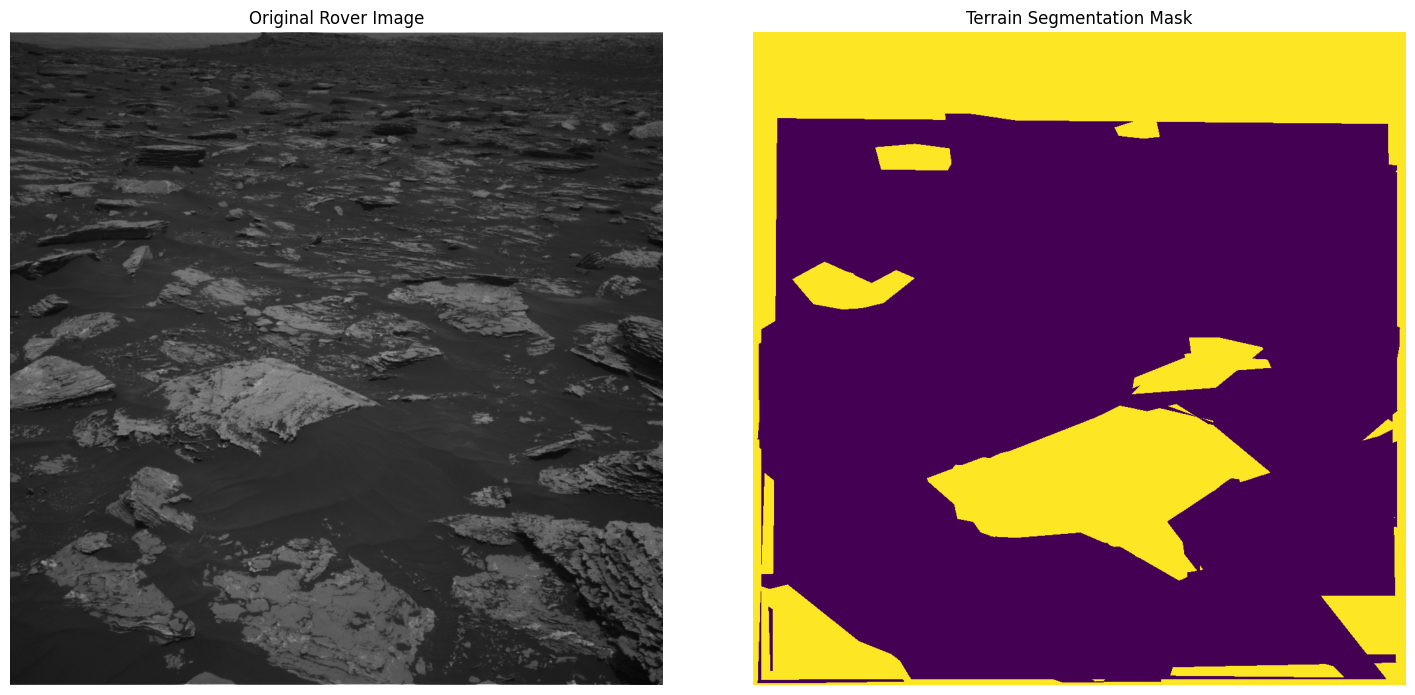

In [9]:
display_image_and_label(image, label,  os.path.join("images", "curiosity.png"))

### Dataset Considerations

We will focus our work on data from the Curiosity Rover (there is already a lot of this). For data preprocessing, we will do the following

* Standardize the colors. We'll ensure all images are greyscale.
* Standardize the sizes. All images will be resized to 512 x 512 pixels. ( NOTE: We will use nearest neighbour scaling to avoid distorting the labels as much as we can )
* Finally, we normalize the data to have mean 0 and standard deviation 1. (Statistical Standardization).

As part of the preprocessing we'll also create a unified dataset we can use for our machine learning model. The dataset as given has non-standard names for each image, and in some cases multiple label files for each image. We'll clean this up and create our own subset of the data for doing our work with.

## Extracting Relevant Datafiles

For our purposes, we are interested in data from the rovers navigational cameras. We'll extract those files, and their labels and combine them into a single data folder.

We'll use the following format: {rover}_{num}.png and {rover}_{num}_label.png

In [10]:
target_image_folder = os.path.join("data", "images")
target_label_folder = os.path.join("data", "labels")

EXTRACT_DATA_SET = False # set to false if the dataset has already been extracted from the source folder.

In [11]:
def find_label_path(label_folder, base_name):
    """
    Finds a given training label for an image.

    Args:
        label_folder: Source folder for the labels.
        base_name: Base name for the image we want the label for.

    Returns:
        The path to the label image if it exists, or None
    """
    base_name = os.path.splitext(base_name)[0]
    label_name = f"{base_name}.png"
    label_path = os.path.join(label_folder, label_name)

    if os.path.exists(label_path):
        return label_path
    

    # handle the Mars Science Label Labels.
    for i in range(3, 10):
        label_name = f"{base_name}_merged{i}.png"
        label_path = os.path.join(label_folder, label_name)

        if os.path.exists(label_path):
            return label_path
    return None

In [12]:
def extract_rover_files(rover_name, image_folder, label_folder):
    """
    Extracts image / label pairs from the target folders and saves them to our datastore.

    Args:
        rover_name:
        image_folder:
        label_folder:
    """
    all_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    transformed_image_count = 0
    missing_label_count = 0

    for index, file_name in enumerate(all_files):
        # load and process the label
        label_path = find_label_path(label_folder, file_name)

        # It seems not every input image has an identifiable label to go with it.
        # We will skip these examples as it seems we still have plenty of data.
        if label_path is None:
            missing_label_count = missing_label_count + 1
            continue

        with Image.open(label_path) as img:
            label_name = f"{rover_name}_{index}_label.png"
            img.save(os.path.join(target_label_folder, label_name))
        
        with Image.open(os.path.join(image_folder, file_name)) as img:
            out_file = f"{rover_name}_{index}.png"
            img.save(os.path.join(target_image_folder, out_file))

        transformed_image_count = transformed_image_count + 1

    print("*****SUMMARY********")
    print(f"Transformed Image: {transformed_image_count}, Missing Images: {missing_label_count}")
        

In [13]:
if EXTRACT_DATA_SET:
    extract_rover_files("curiosity", curiosity_images, curiosity_labels)

## Data Processing Pipeline

First we'll need to create the dataset and split out data into train, test, and validation sets.

In [14]:
data_images = os.path.join("data", "images")
data_labels = os.path.join("data", "labels")

In [15]:
training_ratio = 0.7
validation_ratio = 0.15

In [16]:
class MarsRoverDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        """
        Args:
            images_dir (str): Path to the directory containing raw images.
            labels_dir (str): Path to the directory containing segmentation labels.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform

        self.image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    def __len__(self):
        """
        Returns the number of image_files.
        """
        return len(self.image_files)
        
    def _load_label(self, base_name, img_shape):
        """
        Helper to find and load the corresponding label
        
        Args:
            base_name: The name of the source image (without extension)
            img_shape: The shape of the source image.

        Returns:
            A numpy array representing the mask label
        """
        label_name = f"{base_name}_label.png"
        label_path = os.path.join(self.labels_dir, label_name)
        if not os.path.exists(label_path):
            raise Exception(f"Unable to find label associated with {base_name}")
        
        label_image = np.array(Image.open(label_path))
        
        binary_label = np.copy(label_image)
        binary_label[ (label_image == 0) | (label_image == 1)] = 1 
        binary_label[ (label_image == 2) | (label_image == 3) | (label_image == 255)] = 0
        
        return binary_label

    def __getitem__(self, idx):
        """
        Gets the next image/label pair from the dataset. Source image is loaded in as a greyscale image.

        Args:
            idx: index of the image/label pair to grab.
        """
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        base_name = os.path.splitext(img_name)[0]
        
        img = Image.open(img_path).convert('RGB')
        img_array = np.array(img)
        
        label_array = self._load_label(base_name, img_array.shape)
        label_tensor = torch.from_numpy(label_array).long()
        
        if self.transform:
            img_tensor = self.transform(img)

            h, w = img_tensor.shape[1], img_tensor.shape[2]
                    
            label_tensor = torch.nn.functional.interpolate(
                    label_tensor.unsqueeze(0).unsqueeze(0).float(), 
                    size=(h, w), 
                    mode='nearest'
                ).squeeze(0).squeeze(0).long()

        else:
            img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).float() / 255.0

        return img_tensor, label_tensor


### Standard Dataloader

In [17]:
# Standard Transforms
standard_transform_pipeline = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.Grayscale(num_output_channels=1),       
    transforms.ToTensor(),                             
    transforms.Normalize((0.5,), (0.5,))               
])

In [18]:
standard_dataset = MarsRoverDataset(
    images_dir=data_images, 
    labels_dir=data_labels,
    transform=standard_transform_pipeline
)

In [19]:
# note: We aren't augmenting the data in either case, so these values can be reused for the second pipeline.
total_size = len(standard_dataset)
train_size = int(training_ratio * total_size)
val_size = int(validation_ratio * total_size)
test_size = total_size - train_size - val_size

In [20]:
print(f"Total Size: {total_size}")
print(f"Train Size: {train_size}")
print(f"Validation Size: {val_size}")
print(f"Test Size: {test_size}")

Total Size: 16064
Train Size: 11244
Validation Size: 2409
Test Size: 2411


In [21]:
std_train_dataset, std_val_dataset, std_test_dataset = random_split(
    standard_dataset, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42) 
)

In [22]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

## UNet Components

In [23]:
class ConvBatchRelu(nn.Module):
    def __init__(self, in_channels, out_channels):
        """
        Combines Convolution, Batch Norm, and ReLU into a single operation.

        Args:
            in_channels: Number of input channels
            out_channels: Number of output channels.
        """
        super().__init__()
        self.conv_op = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        """
        Executes the convolutional operation
        
        Args:
            x: input tensor

        Returns:
            Result of running the convolution operation on x.
        """
        return self.conv_op(x)

In [24]:
class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        """
        Downsamples the output of a Convolution using MaxPool.

        Args:
            in_channels: Number of input channels
            out_channels: Number of output channels.
        """
        super().__init__()
        self.conv = ConvBatchRelu(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        """
        Executes a convolution operation followed by MaxPool for downsampling.

        Args:
            x: input tensor

        Returns:
            down: Result of running the convolution operation.
            p: Result of running MaxPool2D on the output of the previous operation.
        """
        down = self.conv(x)
        p = self.pool(down)

        return down, p

In [25]:
class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        """
        Deconvolution to upsample the input

        Args:
            in_channels: Number of input channels
            out_channels: Number of output channels.
        """
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)
        self.conv = ConvBatchRelu(in_channels, out_channels)

    def forward(self, x1, x2):
        """
        Upscale the input tensor
        Concat the input x1 with x2
        Run Convolution on the resulting tensor

        Args:
            x1: input tensor
            x2: redidual tensor from the parralel layer on the encoder.
        
        Returns:
            A tensor representing the final result.
        """
        x1 = self.up(x1)
        x = torch.cat([x1, x2], 1)
        return self.conv(x)

## Standard UNet Model

### Model Definition

We build the model described in the original UNet paper: https://arxiv.org/abs/1505.04597
This blog post: https://medium.com/@fernandopalominocobo/mastering-u-net-a-step-by-step-guide-to-segmentation-from-scratch-with-pytorch-6a17c5916114 was used for guidance in constructing the UNet Model, although we did make some changes - specifically we added Batch Normalization to the process.

In [26]:
class UNet(nn.Module):
    """
    Basic Implementation of UNet.
    """

    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.down_convolution_1 = DownSample(in_channels, 64)
        self.down_convolution_2 = DownSample(64, 128)
        self.down_convolution_3 = DownSample(128, 256)
        self.down_convolution_4 = DownSample(256, 512)

        self.bottle_neck = ConvBatchRelu(512, 1024)

        self.up_convolution_1 = UpSample(1024, 512)
        self.up_convolution_2 = UpSample(512, 256)
        self.up_convolution_3 = UpSample(256, 128)
        self.up_convolution_4 = UpSample(128, 64)

        self.out = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=1)

    def forward(self, x):
        down_1, p1 = self.down_convolution_1(x)
        down_2, p2 = self.down_convolution_2(p1)
        down_3, p3 = self.down_convolution_3(p2)
        down_4, p4 = self.down_convolution_4(p3)

        b = self.bottle_neck(p4)

        up_1 = self.up_convolution_1(b, down_4)
        up_2 = self.up_convolution_2(up_1, down_3)
        up_3 = self.up_convolution_3(up_2, down_2)
        up_4 = self.up_convolution_4(up_3, down_1)

        out = self.out(up_4)
        return out

### Training

Define the model, optimizer and loss.

We will use the DiceLoss for training the model as this loss function has shown promise in other segmentation applications, such as medical imaging.

In [27]:
LEARNING_RATE = 3e-4
TRAIN_MODEL = True
model = UNet(in_channels=1, num_classes=1).to(device) # input images are greyscale, so only 1 channel
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = smp.losses.DiceLoss(
    mode="binary", 
    from_logits=True
)

In [28]:
BATCH_SIZE = 8
num_workers = 0

In [29]:


std_train_dataloader = DataLoader(
                                dataset=std_train_dataset,
                                num_workers=num_workers, 
                                pin_memory=False,
                                batch_size=BATCH_SIZE,
                                shuffle=True
                            )

std_val_dataloader = DataLoader(
                                dataset=std_val_dataset,
                                num_workers=num_workers, 
                                pin_memory=False,
                                batch_size=BATCH_SIZE,
                                shuffle=False
                            )

std_test_dataloader = DataLoader(
                                dataset=std_test_dataset,
                                num_workers=num_workers, 
                                pin_memory=False,
                                batch_size=BATCH_SIZE,
                                shuffle=False
                            )


Sanity check for dataset sizes...

In [30]:

print(f"Training subset: {len(std_train_dataset)}")
print(f"Validation subset: {len(std_val_dataset)}")
print(f"Test subset: {len(std_test_dataset)}")

Training subset: 11244
Validation subset: 2409
Test subset: 2411


In [31]:
torch.cuda.empty_cache()

Model training function - we will reuse this for the comparison model

In [32]:
def train_model(model, epochs, train_dataloader, val_dataloader, model_file=None):
    """
    Trains a semantic segmentation model using pytorch.

    Args:
        model: The model we wish to train.
        epochs: The number of epoches to train the model for.
        train_dataloader: The training dataloader
        val_dataloader: The validation dataloader.
        model_file: The file name to save the model to.

    Returns:
        train_losses: Array of losses from training.
        val_losses: Array of losses from the validation step
    """
    train_losses = []
    val_losses = [] 

    
    for epoch in tqdm(range(epochs)):
        model.train()
        train_running_loss = 0
        
        for idx, img_mask in enumerate(tqdm(train_dataloader, position=0, leave=True)):
            img = img_mask[0].float().to(device)
            mask = img_mask[1].long().to(device)
            
            y_pred = model(img)
            optimizer.zero_grad()
            loss = criterion(y_pred, mask)
            
            train_running_loss += loss.item()
       
            loss.backward()
            optimizer.step()

        train_loss = train_running_loss / (idx + 1)
        
        train_losses.append(train_loss)
       
        model.eval()
        val_running_loss = 0
        
        with torch.no_grad():
            for idx, img_mask in enumerate(tqdm(val_dataloader, position=0, leave=True)):
                img = img_mask[0].float().to(device)
                mask = img_mask[1].long().to(device)

                y_pred = model(img)
                loss = criterion(y_pred, mask)        
                val_running_loss += loss.item()
        
            val_loss = val_running_loss / (idx + 1)
        
        val_losses.append(val_loss)
        
        print("-" * 30)
        print(f"Training Loss EPOCH {epoch + 1}: {train_loss:.4f}")
        print("\n")
        print(f"Validation Loss EPOCH {epoch + 1}: {val_loss:.4f}")
        print("-" * 30)

    if model_file is not None:
        torch.save(model.state_dict(), model_file)
    
    return train_losses, val_losses

In [33]:
def plot_losses(train_losses, val_losses, filename="images/losses.png"):
    """
    Plots the training and validation losses.

    Args:
        train_losses: An array of training losses (obtained from train_model function)
        val_losses: An array of validation losses (obtained from tain_model function)
    """

    plt.figure(figsize=(16, 8))
    plt.plot(train_losses, label='Training Losses', color='green', marker='^')
    plt.plot(val_losses, label='Validation Losses', color='orange', marker='d')
    plt.title("Training and Validation Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.savefig(filename);
    

 20%|██        | 1/5 [1:21:29<5:25:56, 4889.17s/it]

------------------------------
Training Loss EPOCH 1: 0.2059


Validation Loss EPOCH 1: 0.2212
------------------------------


 40%|████      | 2/5 [3:21:59<5:13:18, 6266.18s/it]

------------------------------
Training Loss EPOCH 2: 0.1756


Validation Loss EPOCH 2: 0.1778
------------------------------


 60%|██████    | 3/5 [5:36:11<3:56:03, 7081.52s/it]

------------------------------
Training Loss EPOCH 3: 0.1650


Validation Loss EPOCH 3: 0.1682
------------------------------


 80%|████████  | 4/5 [7:44:05<2:01:55, 7315.50s/it]

------------------------------
Training Loss EPOCH 4: 0.1561


Validation Loss EPOCH 4: 0.1561
------------------------------


100%|██████████| 5/5 [9:58:38<00:00, 7183.79s/it]  


------------------------------
Training Loss EPOCH 5: 0.1515


Validation Loss EPOCH 5: 0.1480
------------------------------


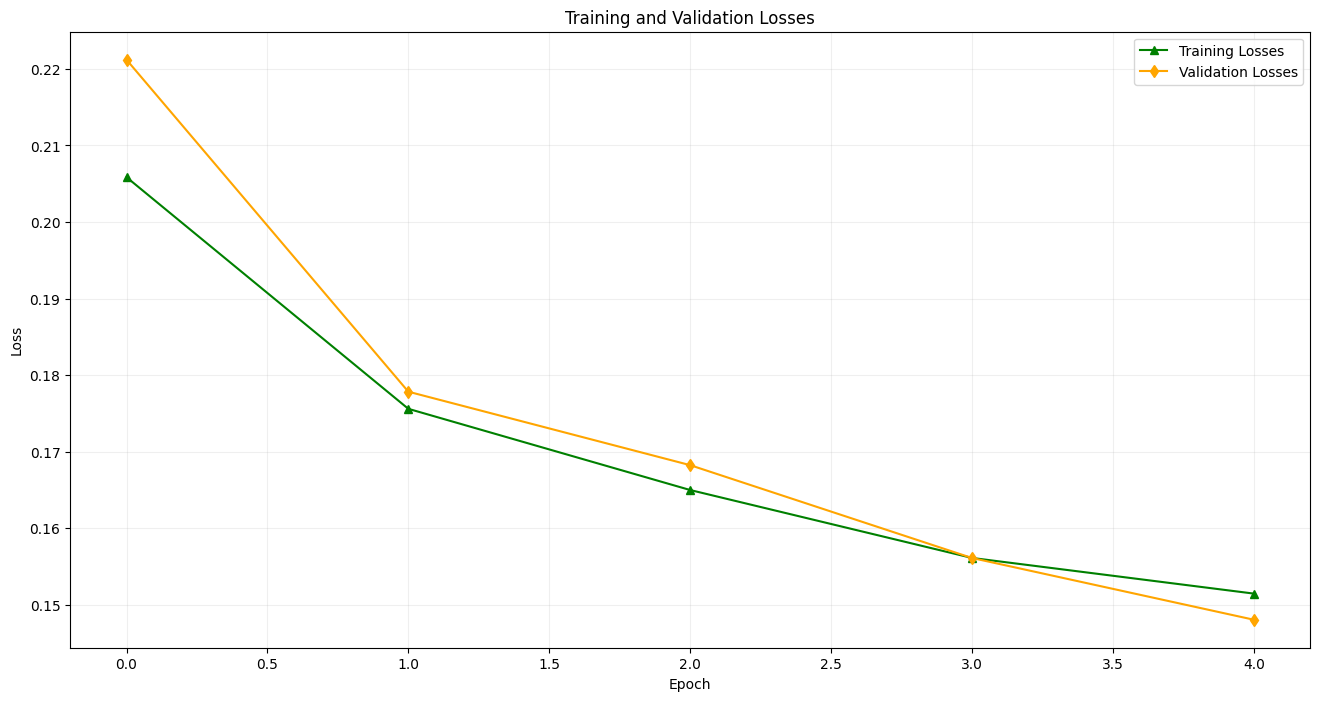

In [36]:
if TRAIN_MODEL:
    train_losses, val_losses = train_model(
        model=model,
        epochs=5,
        train_dataloader=std_train_dataloader,
        val_dataloader=std_val_dataloader,
        model_file="models/standard_unet.pth"
    )

    plot_losses(train_losses, val_losses, "images/standard_unet_losses.png")

### Testing

We will evaluate the performance of this model using the mean Intersection over Union (mIoU) and Dice Score.

Based on https://www.mdpi.com/2072-4292/14/24/6297#:~:text=%5B20%5D%20built%20the%20first%20large,Li%20et%20al. a competitive performance metric for mIoU on this dataset is around 70-80%.



In [34]:
def test_model(model, test_dataloader):
    """
    Tests the final accuracy of the model using mIoU and Dice Score.
    """
    model.eval()
    
    iou_scores = []
    dice_scores = []
    
    with torch.no_grad():
        for img_mask in tqdm(test_dataloader, position=0, leave=True, desc="Testing Model"):
            img = img_mask[0].float().to(device)
            mask = img_mask[1].long().to(device)
            
            mask = mask.unsqueeze(1)
            
            logits = model(img)
            probs = torch.sigmoid(logits) 
            
            tp, fp, fn, tn = smp.metrics.get_stats(
                probs, 
                mask, 
                mode='binary', 
                threshold=0.5
            )
            
            iou_batch = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")
            dice_batch = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro")
            
            iou_scores.append(iou_batch.item())
            dice_scores.append(dice_batch.item())
    mean_iou = np.mean(iou_scores)
    mean_dice = np.mean(dice_scores)
    
    print("-" * 30)
    print(f"Test Mean IoU: {mean_iou:.4f}")
    print(f"Test Mean Dice Score: {mean_dice:.4f}")
    print("-" * 30)
    
    return mean_iou, mean_dice


In [35]:
# load model
if TRAIN_MODEL:
    test_unet = UNet(in_channels=1, num_classes=1).to(device)
    test_unet.load_state_dict(torch.load("models/standard_unet.pth", weights_only=True))
    test_iou, test_dice = test_model(test_unet, std_test_dataloader)

Testing Model: 100%|██████████| 302/302 [01:44<00:00,  2.88it/s]

------------------------------
Test Mean IoU: 0.7621
Test Mean Dice Score: 0.8624
------------------------------


Next we verify that the results we are getting match up with what we expect (to some degree). We'll visualize both ground truth and predicted masks as red = untransversible and green = transversible. This will give us some idea where the model is making mistakes.

In [36]:
def mask_to_rgb(mask_array):
    """
    Converts a 2D mask array into an RGB image.
    Traversable (1) -> Green [0, 255, 0]
    Everything else Red
    """
    # Create an entirely red RGB image by default
    rgb = np.zeros((mask_array.shape[0], mask_array.shape[1], 3), dtype=np.uint8)
    rgb[:, :] = [255, 0, 0]  # Fill with Red
    
    # Overwrite the pixels where the mask is 1 (traversable) with Green
    rgb[mask_array == 1] = [0, 255, 0]  
    
    return rgb

def visualize_predictions(model, dataloader, num_images=3, threshold=0.5, filename=None):
    """
    Visualizes the original image, ground truth mask, and predicted mask side-by-side.
    Colors traversable terrain green and everything else red.
    """
    model.eval()
    images_shown = 0
    
    # Create matplotlib subplots
    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))
    if num_images == 1:
        axes = [axes]
        
    with torch.no_grad():
        for img_mask in dataloader:
            imgs = img_mask[0].float().to(device)
            masks = img_mask[1].long().to(device)
            
            logits = model(imgs)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).long() # threshold binary masks
            
            for i in range(imgs.size(0)):
                if images_shown >= num_images:
                    break
                
                # Move tensors back to CPU for plotting
                img_plot = imgs[i].cpu().squeeze().numpy()
                mask_plot = masks[i].cpu().squeeze().numpy()
                pred_plot = preds[i].cpu().squeeze().numpy()
                
                # 1. Original Image
                axes[images_shown][0].imshow(img_plot, cmap='gray')
                axes[images_shown][0].set_title("Original Rover Image")
                axes[images_shown][0].axis('off')
                
                # 2. Ground Truth Mask (Mapped to Green & Red)
                gt_rgb = mask_to_rgb(mask_plot)
                axes[images_shown][1].imshow(gt_rgb)
                axes[images_shown][1].set_title("Ground Truth Mask")
                axes[images_shown][1].axis('off')
                
                # 3. Predicted Mask (Mapped to Green & Red)
                pred_rgb = mask_to_rgb(pred_plot)
                axes[images_shown][2].imshow(pred_rgb)
                axes[images_shown][2].set_title("Predicted Mask")
                axes[images_shown][2].axis('off')
                
                images_shown += 1
                
            if images_shown >= num_images:
                break
                
    plt.tight_layout()
    
    if filename is None:
        plt.show()
    else:
        plt.savefig(filename)


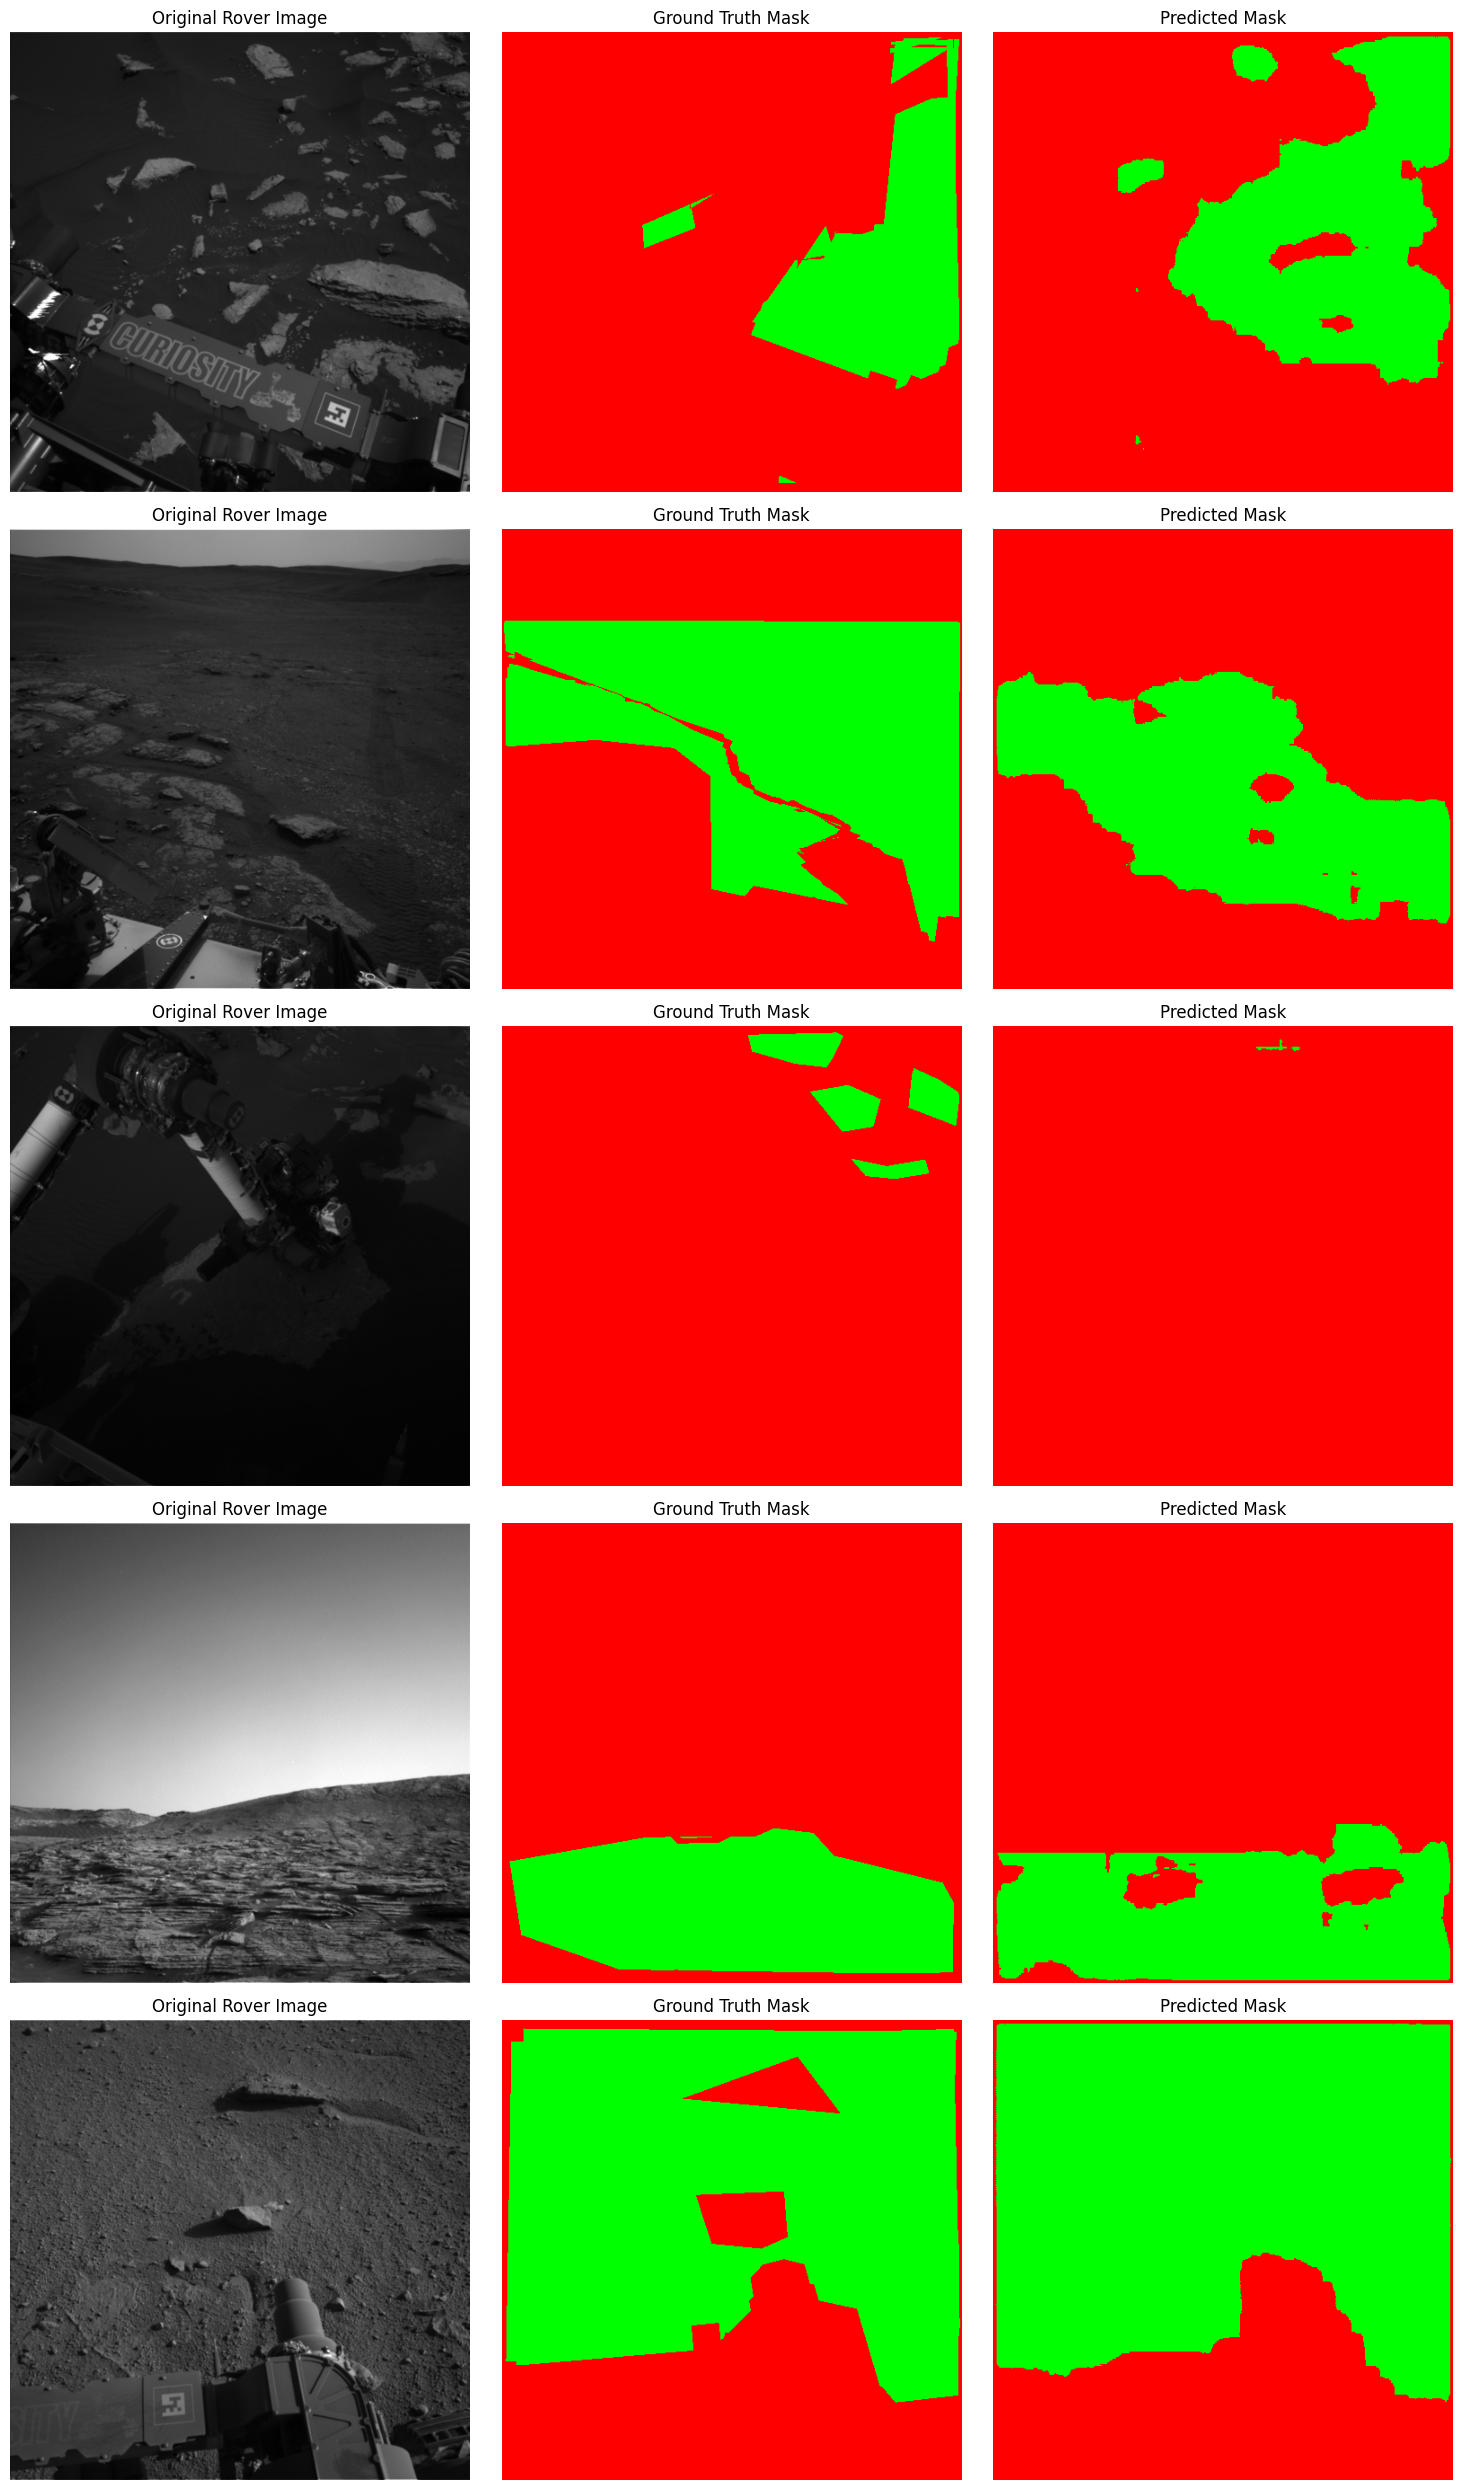

In [37]:
# Visualize 3 samples from the test dataloader
if TRAIN_MODEL:
    visualize_predictions(test_unet, std_test_dataloader, num_images=5, filename="images/unet_segmentation.png")
   

Finally, for compairison purposes, we print out the number of model parameters...

In [38]:
if TRAIN_MODEL:
     print(count_parameters(test_unet))

15329473


## Mini UNet - can we make this model smaller?


In [39]:
# MINI UNet - we shrink the UNet by reducing the number of filters at each step
class MiniUNet(nn.Module):
    """
    Basic Implementation of UNet.
    """

    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.down_convolution_1 = DownSample(in_channels, 16)
        self.down_convolution_2 = DownSample(16, 32)
        self.down_convolution_3 = DownSample(32, 64)
        self.down_convolution_4 = DownSample(64, 128)

        self.bottle_neck = ConvBatchRelu(128, 256)

        self.up_convolution_1 = UpSample(256, 128)
        self.up_convolution_2 = UpSample(128, 64)
        self.up_convolution_3 = UpSample(64, 32)
        self.up_convolution_4 = UpSample(32, 16)

        self.out = nn.Conv2d(in_channels=16, out_channels=num_classes, kernel_size=1)

    def forward(self, x):
        down_1, p1 = self.down_convolution_1(x)
        down_2, p2 = self.down_convolution_2(p1)
        down_3, p3 = self.down_convolution_3(p2)
        down_4, p4 = self.down_convolution_4(p3)

        b = self.bottle_neck(p4)

        up_1 = self.up_convolution_1(b, down_4)
        up_2 = self.up_convolution_2(up_1, down_3)
        up_3 = self.up_convolution_3(up_2, down_2)
        up_4 = self.up_convolution_4(up_3, down_1)

        out = self.out(up_4)
        return out
    

### Train MiniUNet

In [40]:
torch.cuda.empty_cache()

In [41]:
TRAIN_MINI_UNET = True
model = MiniUNet(in_channels=1, num_classes=1).to(device) # input images are greyscale, so only 1 channel
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = smp.losses.DiceLoss(
    mode="binary", 
    from_logits=True
)

 20%|██        | 1/5 [06:07<24:29, 367.29s/it]

------------------------------
Training Loss EPOCH 1: 0.2423


Validation Loss EPOCH 1: 0.1797
------------------------------


 40%|████      | 2/5 [12:12<18:18, 366.24s/it]

------------------------------
Training Loss EPOCH 2: 0.1772


Validation Loss EPOCH 2: 0.1651
------------------------------


 60%|██████    | 3/5 [18:23<12:16, 368.12s/it]

------------------------------
Training Loss EPOCH 3: 0.1621


Validation Loss EPOCH 3: 0.1575
------------------------------


 80%|████████  | 4/5 [24:47<06:14, 374.58s/it]

------------------------------
Training Loss EPOCH 4: 0.1568


Validation Loss EPOCH 4: 0.1882
------------------------------


100%|██████████| 5/5 [31:15<00:00, 375.15s/it]


------------------------------
Training Loss EPOCH 5: 0.1521


Validation Loss EPOCH 5: 0.1480
------------------------------


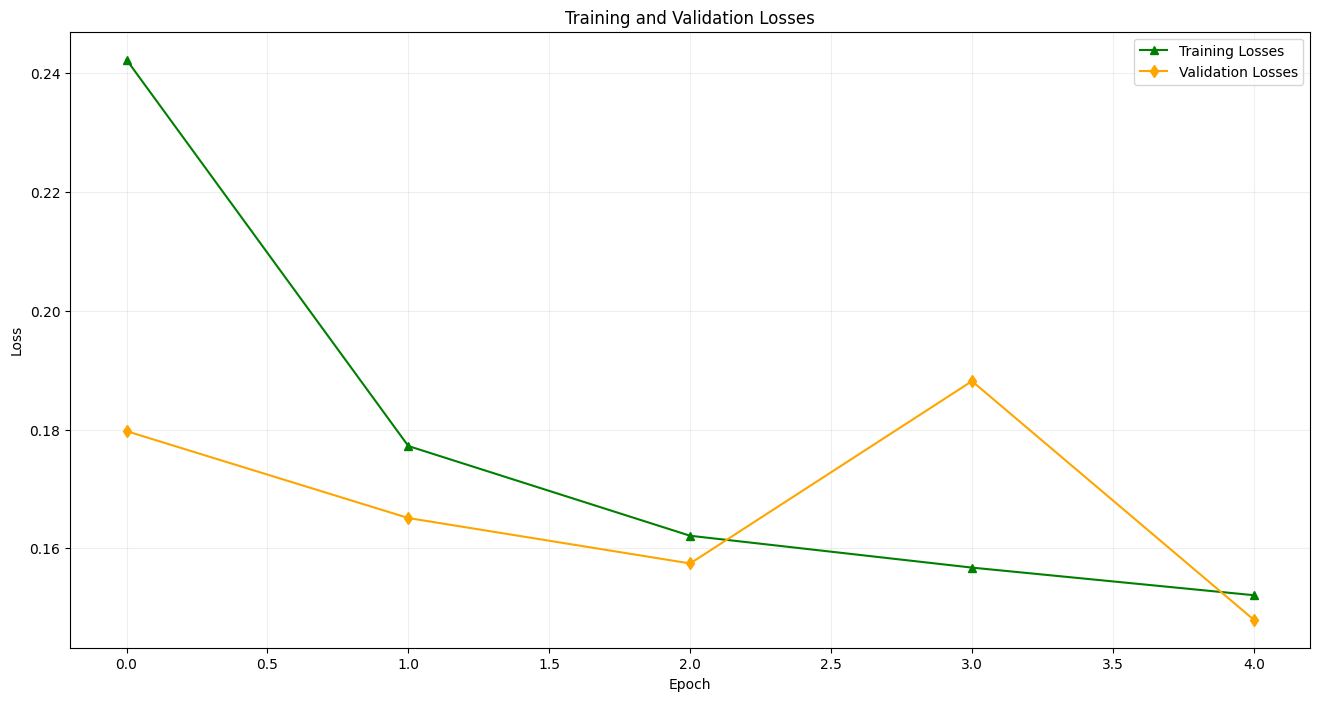

In [ ]:
if TRAIN_MINI_UNET:
    train_losses, val_losses = train_model(
        model=model,
        epochs=5,
        train_dataloader=std_train_dataloader,
        val_dataloader=std_val_dataloader,
        model_file="models/mini_unet.pth"
    )

    plot_losses(train_losses, val_losses, "images/mini_unet.png")

In [42]:
if TRAIN_MINI_UNET:
    test_unet = MiniUNet(in_channels=1, num_classes=1).to(device)
    test_unet.load_state_dict(torch.load("models/mini_unet.pth", weights_only=True))
    test_iou, test_dice = test_model(test_unet, std_test_dataloader)

Testing Model: 100%|██████████| 302/302 [01:08<00:00,  4.41it/s]

------------------------------
Test Mean IoU: 0.7643
Test Mean Dice Score: 0.8640
------------------------------


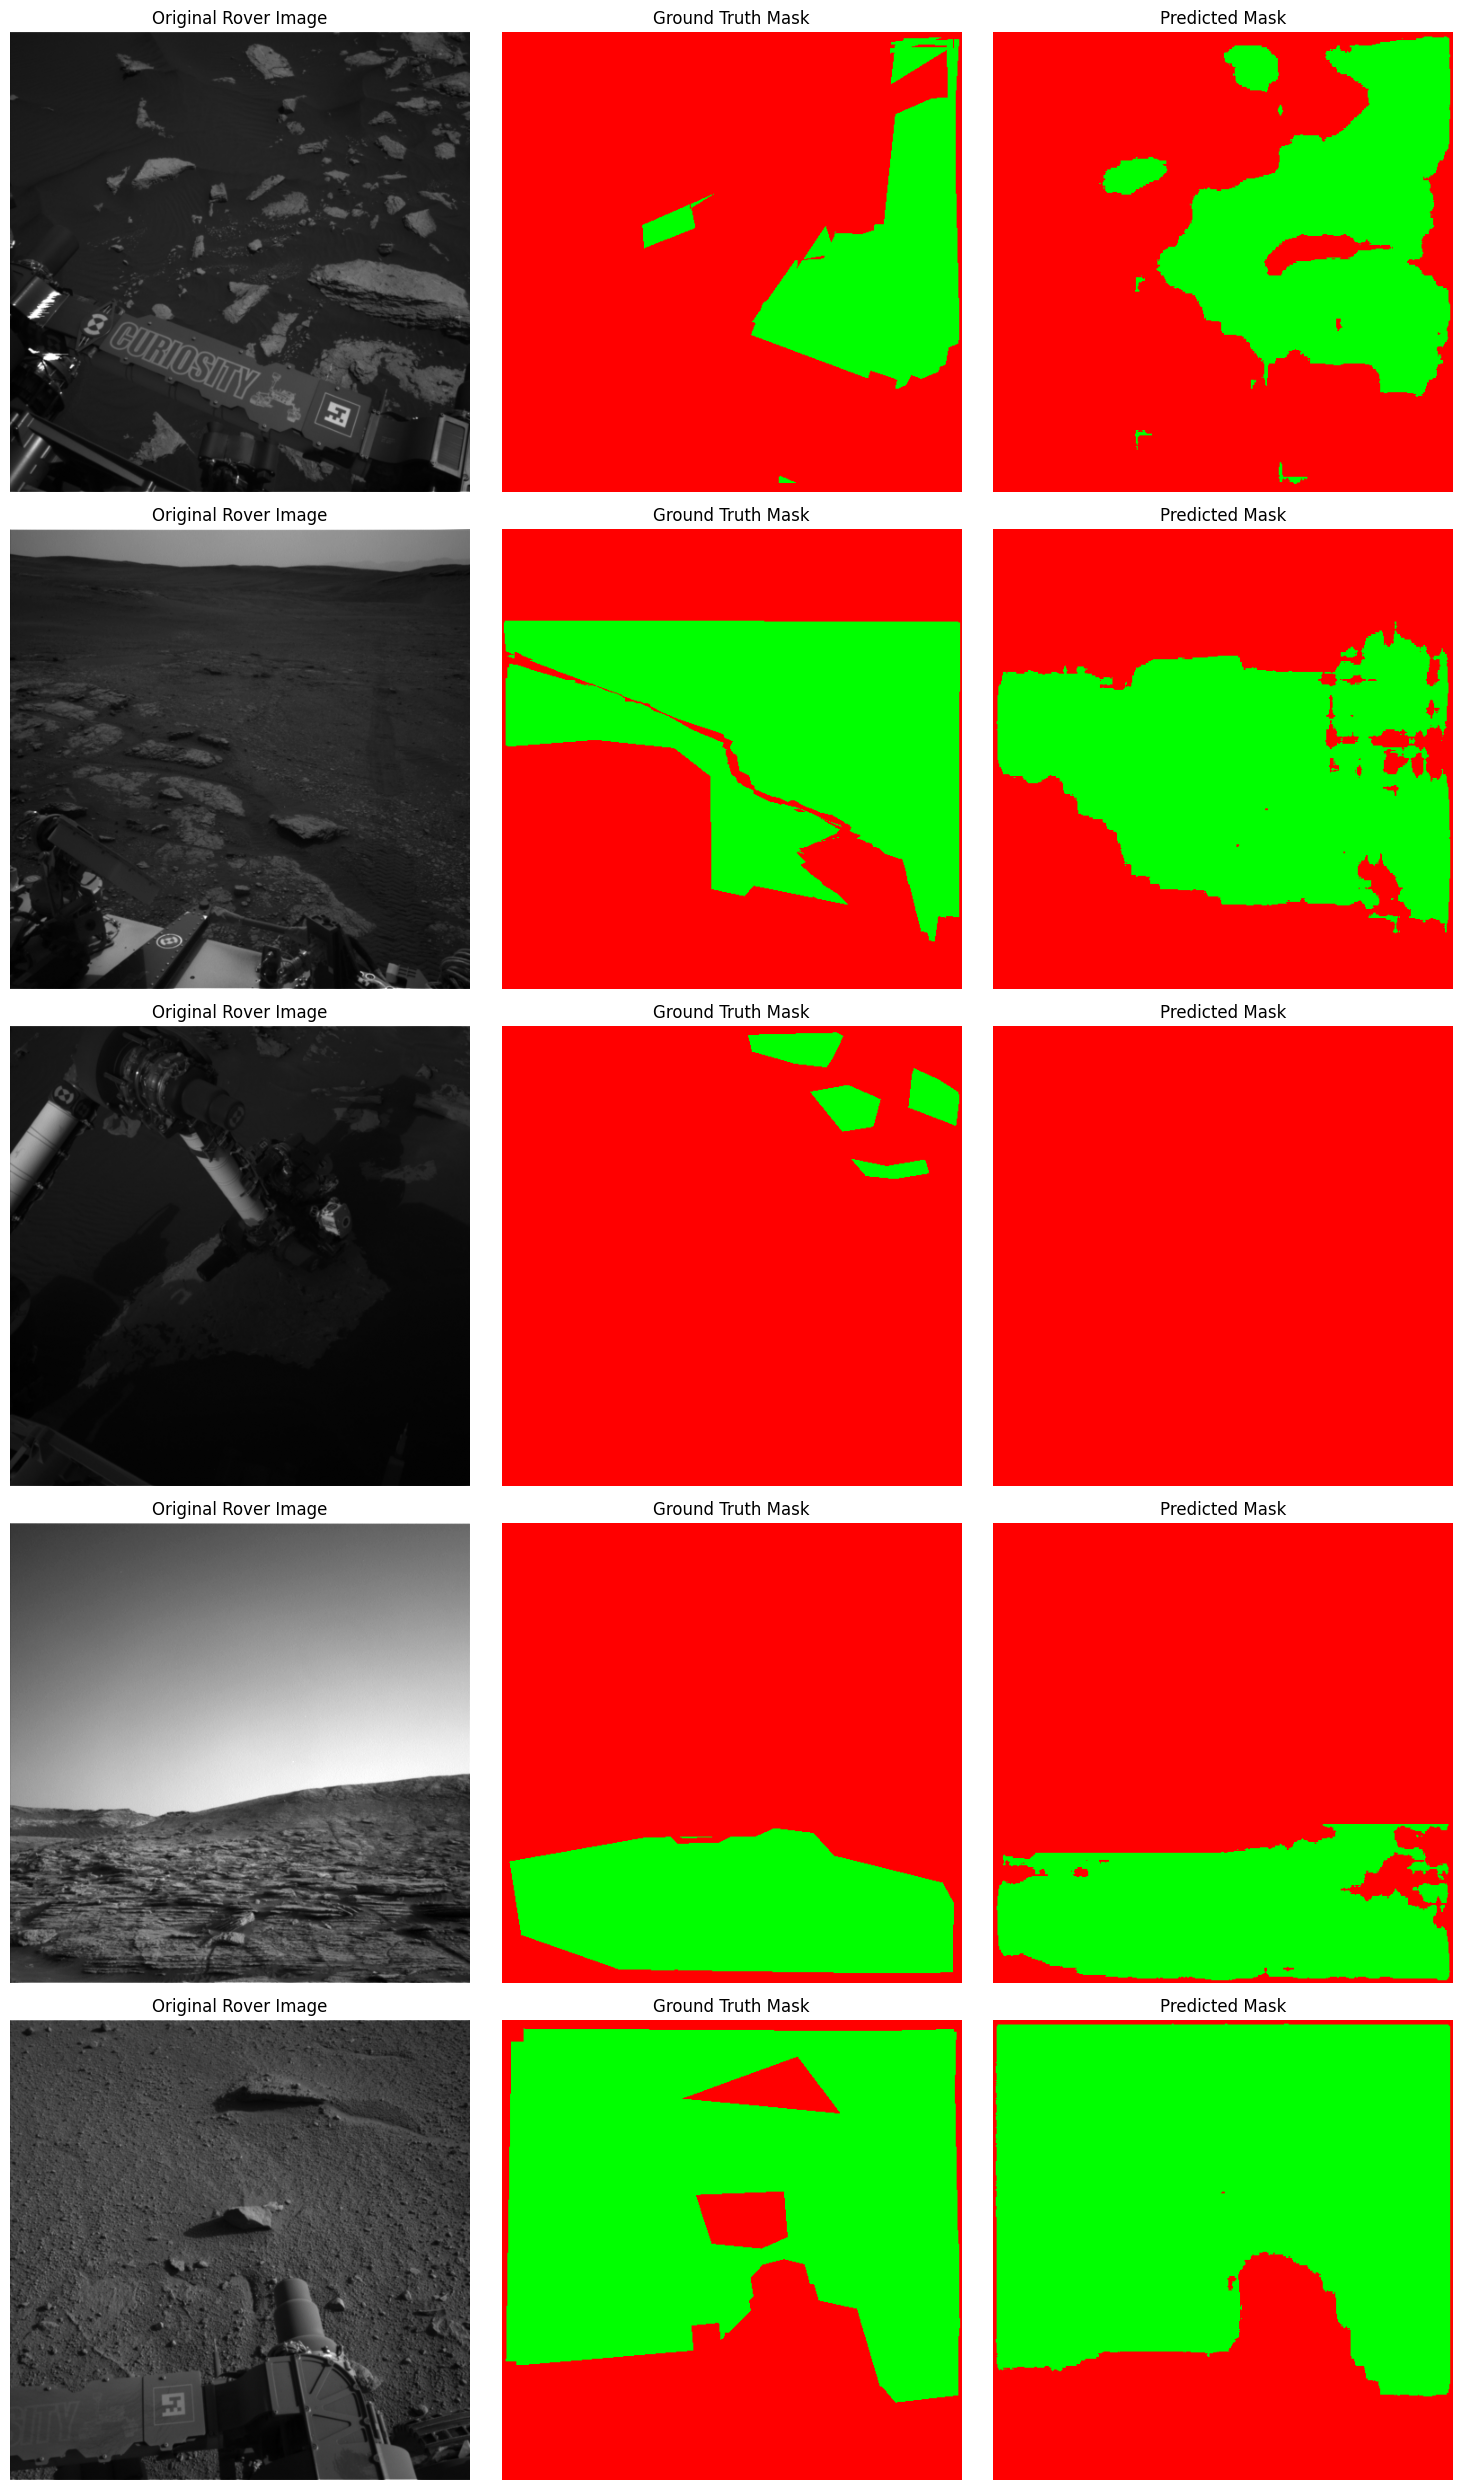

In [43]:
if TRAIN_MINI_UNET:
    visualize_predictions(test_unet, std_test_dataloader, num_images=5, filename="images/mini_unet_segmentation.png")

Determine number of parameters in a single channel Mini UNet

In [44]:
if TRAIN_MINI_UNET:
     print(count_parameters(test_unet))

960049


## Summary

### Experiment

Our task was to see if we could build a smaller UNet and see how the reduced affected the systems performance. This problem was motivated by https://pmc.ncbi.nlm.nih.gov/articles/PMC11820128/ which suggests that smaller networks are not only faster, but have lower power requirements. The idea here is to work towards a deep learning model with low power and storage requirements that could theoretically be used as a navigational aide for a Mars Rover.


We performed a single experiment. 

Our control was a UNet based on the Original UNet paper. This unit had 15329473 parameters.

We trained this model on data extracted from the AI4Mars dataset. Specifically we focused on greyscale images produced by the Curiosity Rover. We did not augment the data in anyway.

We peformed the following transformations on each training image:
* Resize to 512x512. Note: Labels were also resized using Nearest Neighbour. This method was choosen to avoid corrupting the labels.
* Normalize the image assuming a mean of 0.5 and standard deviation of 0.5.

This set of transformations was kept constant for both models to provide an accurate compairison.

We transformed the labels so that they became a binary classification problem - marking pixels as either transversable or non-transversable.

We compared this model against a "Mini-UNet". The Mini-UNet has the same architecture as the full UNet, with the primary difference being a reduction in the number of filters in each layer of the encoders by 50%.

The Mini-UNet had 960049 parameters.

Both models were trained using an Atom Optimizer with a learning rate of 3e-4 for five epochs using Dice Loss.

After training, both models were evaluated using two metrics: Dice Coefficient and Mean Intersection over Union (mIoU).

We also outputed samples of the results from five identical images so we could visually compare the performance.

Models were trained on a NVIDIA GeForce RTX 5070

### Results

#### UNet
* **Dice Coefficient**: 0.86
* **mIoU**: 0.76
* **Training Time**: 588m 34s
* **Test Time**: 1m 30s

#### Mini-UNet
* **Dice Coeffcient**: 0.76
* **mIoU**: 0.76
* **Training Time**: 31m 15.9s
* **Test Time**: 1m 3.9s

### Observations

Surprisingly, shrinking the number of parameters of the UNet by 50% produced comparable results - despite having significantly fewer parameters and requiring significantly less time to train. This is important as it means we may not need a full-sized UNet to solve this problem - its possible we could use this smaller and far less resource intensive model as a basis for a navigational system instead!

However, should we do so, we should keep in mind that both models still missed dangerous features. Looking at the final row of the semantic segmentation output from both models, we see they both failed to recognize the two large (and quite dangerous) rocks in the Rovers path. Its possible they may have picked these up with further training, but if not the algorithm should either be adjusted, or augmented with other sensor data.